> Imports

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_01 import get_data, clean_data

> Load data from previous phases

---



Using Colab cache for faster access to the 'ames-housing-dataset' dataset.


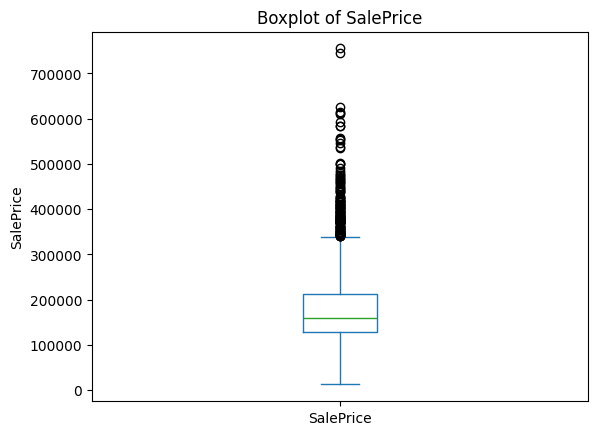

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,rl,141.0,31770,Pave,Unknown,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,rh,80.0,11622,Pave,Unknown,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,rl,81.0,14267,Pave,Unknown,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,rl,93.0,11160,Pave,Unknown,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,rl,74.0,13830,Pave,Unknown,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900.0


In [ ]:
data = get_data()

cleaned_df, dup_count = clean_data(data)

cleaned_df.head()

> Histograms / KDE

---





```
The distributions show that SalePrice and Lot Area are right-skewed,
 meaning most houses are in the lower range with few high values.
```



In [ ]:
def plot_histograms(df):

    cols = ["SalePrice", "Gr Liv Area", "Lot Area"]

    for col in cols:
        plt.figure()
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

> Grouped boxplots

---





```
Higher kitchen and overall quality are associated with higher house prices.
```



In [ ]:
def plot_boxplots(df):

    plt.figure()
    sns.boxplot(x="Kitchen Qual", y="SalePrice", data=df)
    plt.title("SalePrice by Kitchen Quality")
    plt.show()

    plt.figure()
    sns.boxplot(x="Overall Qual", y="SalePrice", data=df)
    plt.title("SalePrice by Overall Quality")
    plt.show()

>

> Correlation heatmap

---





```
Overall Qual and Gr Liv Area have the strongest correlation with SalePrice.
```



In [ ]:
def plot_correlation_heatmap(df):

    corr = df.corr(numeric_only=True)["SalePrice"].abs().sort_values(ascending=False).head(10)
    top_cols = corr.index

    plt.figure(figsize=(8,6))
    sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Top Correlated Features with SalePrice")
    plt.show()

> Scatter plot

---





```
There is a positive relationship between living area and price, but it becomes weaker for very large houses.
```



In [ ]:
def plot_scatter(df):

    plt.figure()
    sns.scatterplot(x="Gr Liv Area", y="SalePrice", hue="Overall Qual", data=df)
    plt.title("Living Area vs SalePrice")
    plt.show()

> Groupby summary

---





```
Houses with higher overall quality have the highest average prices.
```



In [ ]:
def groupby_summary(df):

    summary = df.groupby("Overall Qual")["SalePrice"].mean()

    print(summary.sort_values())

    print("\nHighest:", summary.idxmax(), summary.max())
    print("Lowest:", summary.idxmin(), summary.min())

> Run EDA

---



In [ ]:
def run_eda(df):

    plot_histograms(df)
    plot_boxplots(df)
    plot_correlation_heatmap(df)
    plot_scatter(df)


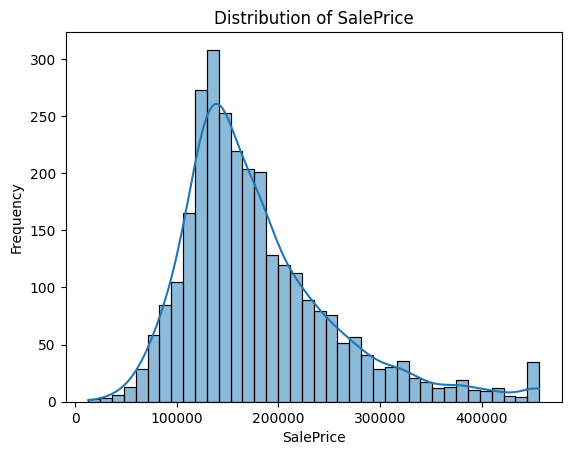

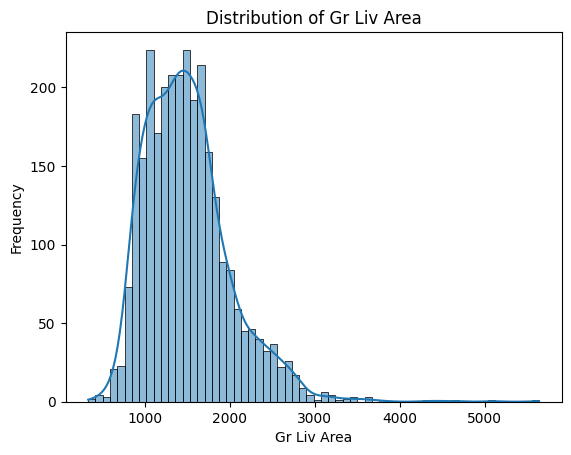

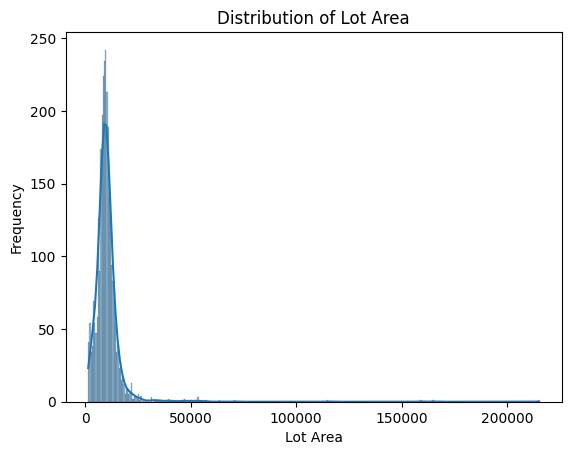

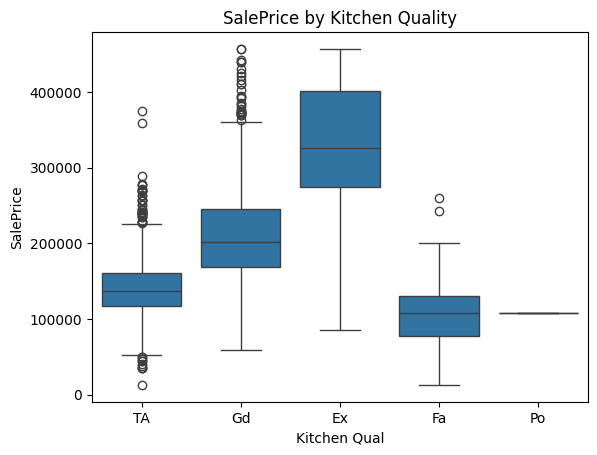

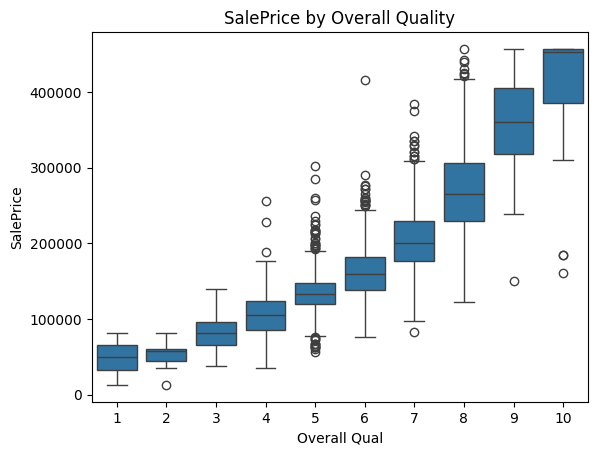

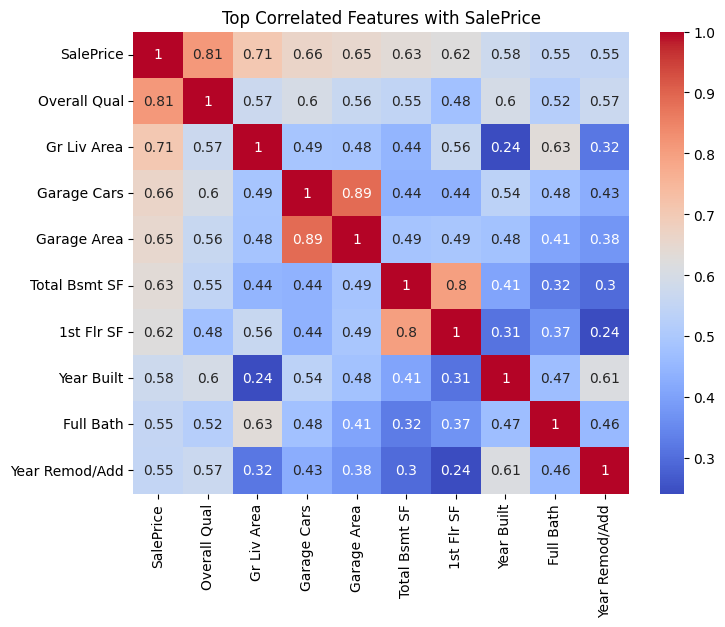

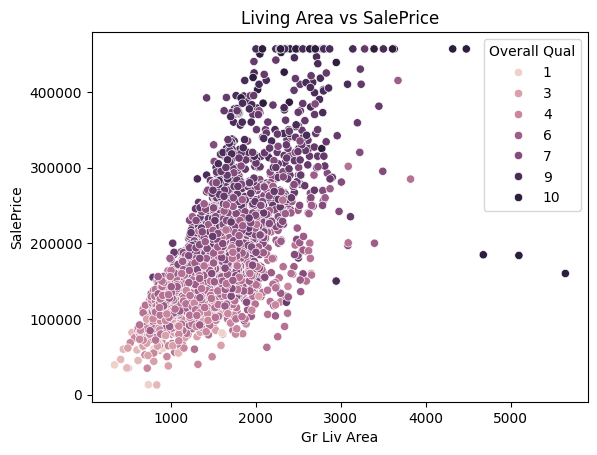

In [ ]:
run_eda(cleaned_df)